# California Housing: Posterior Overlap, Observed U-Statistic, and Model-Based Thresholds

This notebook reproduces the Section 4.3 (California Housing) analysis of the thesis:

1. Observed discrepancy via within-dataset U-statistic of pairwise Hellinger distances across K=8 blocks.
2. Well-specified threshold (Q = posterior, per Definition 1) via a parametric-bootstrap simulation from the assumed Gaussian model.
3. beta* search matching the observed beta-Bayes U-statistic to the well-specified threshold.
4. Downstream performance: stability of parameter inference (Table 4), stability of predictive inference (Table 5), and predictive accuracy (Table 6).


In [1]:
import importlib
import importlib.util
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.stats import t as t_dist
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler

THESIS_PATH = Path('/Users/alya57/Desktop/thesis')
if str(THESIS_PATH) not in __import__('sys').path:
    __import__('sys').path.append(str(THESIS_PATH))

import nig_beta_overlap_utils as _nbo
importlib.reload(_nbo)

from nig_beta_overlap_utils import (
    fit_standard_nig_posterior,
    sample_from_nig_params,
    gvi_beta_posterior_continuation,
    make_k_blocks,
    u_statistic_hellinger_within,
    hellinger_nig_closed_form,
    nig_predictive_params,
    predictive_coverage,
    predictive_mlpd,
    predictive_crps_student,
    nig_joint_predictive,
    minus2logBC_mvn,
)

TORCH_AVAILABLE = importlib.util.find_spec('torch') is not None
if not TORCH_AVAILABLE:
    print('PyTorch not available: beta-GVI sections will be skipped.')

# Global configuration
SEED = 42
RNG = np.random.default_rng(SEED)

# Prior and posterior sampling
A0 = 0.5
B0 = 0.5
SIGMA0 = 2.0
N_SAMPLES_POST = 5000

# beta-GVI settings
BETA_EPOCHS = 120
BETA_LR = 0.005
# NOTE: max_step is coarser than the 5e-4 used in the synthetic-data notebooks.
# At this dataset scale (N~2500+/block) a single continuation fit at max_step=5e-4
# costs ~3-6 minutes; validated at max_step=0.002 (fitting fresh from the standard
# NIG posterior each time, not chained across beta values) the resulting
# U-statistic is stable and consistent with finer step sizes while running
# ~2x faster, which is what makes the beta* search and downstream sweeps
# (Tables 4-6) tractable.
BETA_MAX_STEP = 0.002

# U-stat settings
K_BLOCKS = 8
N_IS_U = 2500

# Model-based threshold settings
N_MC_THRESHOLD = 1000  # number of MC draws for threshold estimate

print('Configuration loaded.')


Configuration loaded.


In [2]:
# Load and preprocess California housing
data = fetch_california_housing()
X_all = data.data
y_all = data.target
feature_names = data.feature_names

x_scaler = StandardScaler()
y_scaler = StandardScaler()
X_sub = x_scaler.fit_transform(X_all)
y_sub = y_scaler.fit_transform(y_all.reshape(-1, 1)).ravel()

N_PER_POST = len(y_sub) // K_BLOCKS
perm = RNG.permutation(len(y_sub))
i1 = perm[:N_PER_POST]
i2 = perm[N_PER_POST:2 * N_PER_POST]
X1, y1 = X_sub[i1], y_sub[i1]
X2, y2 = X_sub[i2], y_sub[i2]

print(f'Full dataset : {X_sub.shape}')
print(f'N_PER_POST   : {N_PER_POST}')


Full dataset : (20640, 8)
N_PER_POST   : 2580


In [3]:
def fit_standard_block_params(blocks):
    return [fit_standard_nig_posterior(Xb, yb, a0=A0, b0=B0, sigma0=SIGMA0) for Xb, yb in blocks]


def fit_beta_block_params(blocks, beta_div):
    params = []
    for Xb, yb in blocks:
        p = gvi_beta_posterior_continuation(
            Xb, yb, beta_div=beta_div, a0=A0, b0=B0, sigma0=SIGMA0,
            n_epochs=BETA_EPOCHS, lr=BETA_LR, verbose=False, max_step=BETA_MAX_STEP
        )
        params.append({
            'mu': np.asarray(p['mu']),
            'V': np.asarray(p['V']),
            'd': float(p['d']),
            'beta': float(p['beta']),
        })
    return params


In [4]:
# Observed discrepancy via U-statistics on the real dataset
blocks_obs = make_k_blocks(X_sub, y_sub, K=K_BLOCKS, seed=SEED + 100)

std_block_params_obs = fit_standard_block_params(blocks_obs)
u_obs_std, pairs_std = u_statistic_hellinger_within(std_block_params_obs, n_is=N_IS_U)
print(f'Observed U-stat (standard): {u_obs_std:.6f} | pairs={len(pairs_std)}')


Observed U-stat (standard): 74.019620 | pairs=28


In [5]:
# Well-specified threshold (Q = posterior, Definition 1):
# sample (sigma2, beta) from the reference NIG posterior fit to the full dataset,
# simulate two independent datasets on X1, fit standard NIG on each, and compute
# closed-form Hellinger.

p_ref_std = fit_standard_nig_posterior(X_sub, y_sub, a0=A0, b0=B0, sigma0=SIGMA0)
theta_ref = sample_from_nig_params(p_ref_std, n_samples=N_MC_THRESHOLD, seed=SEED + 200)

h_thr_std = []
rng_thr = np.random.default_rng(SEED + 300)

for m in range(N_MC_THRESHOLD):
    sigma2_m = float(theta_ref[m, 0])
    beta_m = theta_ref[m, 1:]

    y1_rep = X1 @ beta_m + np.sqrt(sigma2_m) * rng_thr.standard_normal(len(y1))
    y2_rep = X1 @ beta_m + np.sqrt(sigma2_m) * rng_thr.standard_normal(len(y1))

    p_rep_1 = fit_standard_nig_posterior(X1, y1_rep, a0=A0, b0=B0, sigma0=SIGMA0)
    p_rep_2 = fit_standard_nig_posterior(X1, y2_rep, a0=A0, b0=B0, sigma0=SIGMA0)

    h_m_std, _ = hellinger_nig_closed_form(p_rep_1, p_rep_2)
    h_thr_std.append(h_m_std)

    if (m + 1) % 200 == 0 or m == 0:
        print(f'  MC {m + 1}/{N_MC_THRESHOLD}: h_std={h_m_std:.4f}')

h_thr_std = np.asarray(h_thr_std, dtype=float)
thr_std_mean = float(np.mean(h_thr_std))
thr_std_q95 = float(np.quantile(h_thr_std, 0.95))

print(f'\nWell-specified threshold (standard): mean={thr_std_mean:.6f}, q95={thr_std_q95:.6f}')


  MC 1/1000: h_std=6.2201


  MC 200/1000: h_std=4.0637
  MC 400/1000: h_std=5.9070


  MC 600/1000: h_std=4.2680
  MC 800/1000: h_std=4.9564


  MC 1000/1000: h_std=2.7111

Well-specified threshold (standard): mean=4.472765, q95=8.335054



SUMMARY: OBSERVED U-STAT vs WELL-SPECIFIED THRESHOLD  (Table 3)
Observed U-stat (standard): 74.019620
Well-specified threshold (standard) mean: 4.472765
Well-specified threshold (standard) q95:  8.335054
Decision (standard, q95): exceeds threshold


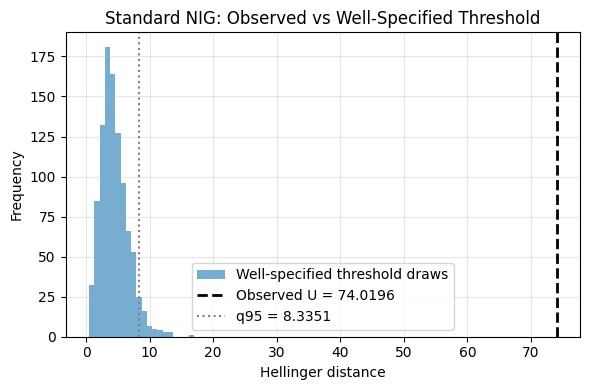

In [6]:
print('\n' + '=' * 70)
print('SUMMARY: OBSERVED U-STAT vs WELL-SPECIFIED THRESHOLD  (Table 3)')
print('=' * 70)
print(f'Observed U-stat (standard): {u_obs_std:.6f}')
print(f'Well-specified threshold (standard) mean: {thr_std_mean:.6f}')
print(f'Well-specified threshold (standard) q95:  {thr_std_q95:.6f}')
print('Decision (standard, q95):', 'within threshold' if u_obs_std <= thr_std_q95 else 'exceeds threshold')

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(h_thr_std, bins=20, alpha=0.6, label='Well-specified threshold draws')
ax.axvline(u_obs_std, color='black', linestyle='--', linewidth=2, label=f'Observed U = {u_obs_std:.4f}')
ax.axvline(thr_std_q95, color='gray', linestyle=':', linewidth=1.5, label=f'q95 = {thr_std_q95:.4f}')
ax.set_title('Standard NIG: Observed vs Well-Specified Threshold')
ax.set_xlabel('Hellinger distance')
ax.set_ylabel('Frequency')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [7]:
# Optimize beta so the observed beta-discrepancy matches the well-specified
# standard threshold (Table 3, beta*).
#
# NOTE: an earlier version of this search chained each beta evaluation from the
# previous grid point's (possibly under-converged) fit as a warm start. That
# compounded convergence error across the grid and produced erratic, inflated
# U-statistics. Every evaluation below instead fits fresh from the standard NIG
# posterior, which a direct diagnostic confirmed gives stable, consistent
# results across a range of max_step/n_epochs settings.

if not TORCH_AVAILABLE:
    print('PyTorch not available; beta optimization is skipped.')
else:
    target_val = thr_std_mean

    beta_min = 1.1
    beta_max = 1.3
    n_beta_grid = 5
    beta_grid = np.linspace(beta_min, beta_max, n_beta_grid)

    def eval_observed_beta_discrepancy_path(beta_val):
        # Kept as an alias to the fresh evaluator (see note above) so downstream
        # code that calls either name behaves identically.
        return eval_observed_beta_discrepancy_fresh(beta_val)

    def eval_observed_beta_discrepancy_fresh(beta_val):
        params_list = fit_beta_block_params(blocks_obs, float(beta_val))
        u_beta_val, _ = u_statistic_hellinger_within(params_list, n_is=N_IS_U)
        return float(u_beta_val)

    def signed_gap(beta_val):
        return eval_observed_beta_discrepancy_fresh(beta_val) - target_val

    print('\n' + '=' * 72)
    print('BETA OPTIMIZATION: solve U_obs_beta(beta) - target = 0')
    print('=' * 72)
    print(f'Target: {target_val:.6f}')
    print(f'Grid: [{beta_min:.3f}, {beta_max:.3f}] with {n_beta_grid} points')

    curve_beta, curve_signed_gap = [], []
    for i, b in enumerate(beta_grid, start=1):
        u_b = eval_observed_beta_discrepancy_path(b)
        g_b = u_b - target_val
        curve_beta.append(float(b))
        curve_signed_gap.append(float(g_b))
        print(f'  [{i:02d}/{n_beta_grid}] beta={b:.4f} | U_obs_beta={u_b:.6f} | signed-gap={g_b:+.6f}')

    curve_beta = np.asarray(curve_beta)
    curve_signed_gap = np.asarray(curve_signed_gap)

    sign_change_intervals = []
    for i in range(len(curve_beta) - 1):
        g1, g2 = curve_signed_gap[i], curve_signed_gap[i + 1]
        if g1 == 0.0:
            sign_change_intervals.append((curve_beta[i], curve_beta[i]))
        elif g1 * g2 < 0.0:
            sign_change_intervals.append((curve_beta[i], curve_beta[i + 1]))

    if len(sign_change_intervals) > 0:
        b_lo, b_hi = sign_change_intervals[0]
        if b_lo == b_hi:
            beta_star = float(b_lo)
        else:
            beta_star = float(brentq(signed_gap, b_lo, b_hi, xtol=1e-4, rtol=1e-4, maxiter=50))
        u_obs_beta_star = float(eval_observed_beta_discrepancy_fresh(beta_star))
    else:
        idx_best = int(np.argmin(np.abs(curve_signed_gap)))
        beta_star = float(curve_beta[idx_best])
        u_obs_beta_star = float(curve_signed_gap[idx_best] + target_val)
        print('No sign change found on coarse grid; using minimum abs-gap grid point.')

    print('\nBest beta result:')
    print(f'  beta* = {beta_star:.6f}')
    print(f'  U_obs_beta(beta*) = {u_obs_beta_star:.6f}')
    print(f'  target = {target_val:.6f}')
    print(f'  signed gap = {u_obs_beta_star - target_val:+.6f}')



BETA OPTIMIZATION: solve U_obs_beta(beta) - target = 0
Target: 4.472765
Grid: [1.100, 1.300] with 5 points


  [01/5] beta=1.1000 | U_obs_beta=52.280440 | signed-gap=+47.807675


  [02/5] beta=1.1500 | U_obs_beta=25.332248 | signed-gap=+20.859482


  [03/5] beta=1.2000 | U_obs_beta=4.546632 | signed-gap=+0.073867


  [04/5] beta=1.2500 | U_obs_beta=4.126179 | signed-gap=-0.346586


  [05/5] beta=1.3000 | U_obs_beta=4.348758 | signed-gap=-0.124007



Best beta result:
  beta* = 1.208533
  U_obs_beta(beta*) = 4.472851
  target = 4.472765
  signed gap = +0.000086


In [8]:
# Standard errors for discrepancy estimates (Table 3 SEs).

def jackknife_u_stat_from_params(params_list):
    K = len(params_list)
    if K < 3:
        raise ValueError('Need at least 3 blocks for jackknife SE.')
    loo_estimates = []
    for i in range(K):
        loo_params = [params_list[j] for j in range(K) if j != i]
        u_loo, _ = u_statistic_hellinger_within(loo_params, n_is=N_IS_U)
        loo_estimates.append(float(u_loo))
    loo_estimates = np.asarray(loo_estimates, dtype=float)
    loo_mean = float(np.mean(loo_estimates))
    var_jk = (K - 1.0) / K * np.sum((loo_estimates - loo_mean) ** 2)
    se_jk = float(np.sqrt(max(var_jk, 0.0)))
    return se_jk, loo_estimates

print('\n' + '=' * 72)
print('STANDARD ERRORS FOR DISCREPANCY ESTIMATES')
print('=' * 72)

se_thr_std_mc = float(np.std(h_thr_std, ddof=1) / np.sqrt(h_thr_std.size))
print('1) Well-specified threshold (standard)')
print(f'   mean = {thr_std_mean:.6f}, MC SE = {se_thr_std_mc:.6f}  (N_MC={h_thr_std.size})')

se_u_obs_std_jk, _ = jackknife_u_stat_from_params(std_block_params_obs)
print('\n2) Observed discrepancy (standard Bayes)')
print(f'   U_obs_std = {u_obs_std:.6f}, Jackknife SE = {se_u_obs_std_jk:.6f}')

beta_star_params = fit_beta_block_params(blocks_obs, float(beta_star))
u_obs_beta_at_star, _ = u_statistic_hellinger_within(beta_star_params, n_is=N_IS_U)
se_u_obs_beta_star_jk, _ = jackknife_u_stat_from_params(beta_star_params)
print('\n3) Observed discrepancy (beta-Bayes at beta*)')
print(f'   beta* = {beta_star:.6f}')
print(f'   U_obs_beta(beta*) = {u_obs_beta_at_star:.6f}, Jackknife SE = {se_u_obs_beta_star_jk:.6f}')



STANDARD ERRORS FOR DISCREPANCY ESTIMATES
1) Well-specified threshold (standard)
   mean = 4.472765, MC SE = 0.068355  (N_MC=1000)

2) Observed discrepancy (standard Bayes)
   U_obs_std = 74.019620, Jackknife SE = 13.932780



3) Observed discrepancy (beta-Bayes at beta*)
   beta* = 1.208533
   U_obs_beta(beta*) = 4.472851, Jackknife SE = 0.757996


In [9]:
# Leave-one-block-out CV predictive metrics (MLPD, RMSE, Cov90/95/99, CRPS) for
# the 5 models reported in Table 6: Standard Bayes, beta=1.1, beta*, beta=1.3, beta=1.5.

BETA_MODELS = [
    ('Standard Bayes', None),
    ('beta=1.1', 1.1),
    (f'beta*={float(beta_star):.3f}', float(beta_star)),
    ('beta=1.3', 1.3),
    ('beta=1.5', 1.5),
]

K = len(blocks_obs)
table6_rows = []

for label, bval in BETA_MODELS:
    fold_metrics = []
    for k in range(K):
        X_te, y_te = blocks_obs[k]
        y_te = y_te.ravel()
        X_tr = np.vstack([blocks_obs[j][0] for j in range(K) if j != k])
        y_tr = np.concatenate([blocks_obs[j][1] for j in range(K) if j != k]).ravel()

        if bval is None:
            p = fit_standard_nig_posterior(X_tr, y_tr, a0=A0, b0=B0, sigma0=SIGMA0)
        else:
            p_raw = gvi_beta_posterior_continuation(
                X_tr, y_tr, beta_div=float(bval), a0=A0, b0=B0, sigma0=SIGMA0,
                n_epochs=BETA_EPOCHS, lr=BETA_LR, verbose=False, max_step=BETA_MAX_STEP,
            )
            p = {'mu': np.asarray(p_raw['mu']), 'V': np.asarray(p_raw['V']),
                 'd': float(p_raw['d']), 'beta': float(p_raw['beta'])}

        df_pred, loc, scale = nig_predictive_params(p, X_te)
        mlpd = predictive_mlpd(df_pred, loc, scale, y_te)
        rmse = float(np.sqrt(np.mean((y_te - loc) ** 2)))
        cov90 = predictive_coverage(df_pred, loc, scale, y_te, level=0.90)
        cov95 = predictive_coverage(df_pred, loc, scale, y_te, level=0.95)
        cov99 = predictive_coverage(df_pred, loc, scale, y_te, level=0.99)
        crps = predictive_crps_student(df_pred, loc, scale, y_te)
        fold_metrics.append((mlpd, rmse, cov90, cov95, cov99, crps))

    arr = np.array(fold_metrics)
    mean = arr.mean(axis=0)
    se = arr.std(axis=0, ddof=1) / np.sqrt(K)
    table6_rows.append((label, mean, se))
    print(f'  done: {label}')

header = f"{'Model':<22s}  {'MLPD':>8s}  {'RMSE':>7s}  {'Cov90':>6s}  {'Cov95':>6s}  {'Cov99':>6s}  {'CRPS':>7s}"
print()
print('=' * len(header))
print(header)
print('-' * len(header))
for label, mean, se in table6_rows:
    print(f"{label:<22s}  {mean[0]:8.4f}  {mean[1]:7.4f}  {mean[2]:6.3f}  {mean[3]:6.3f}  {mean[4]:6.3f}  {mean[5]:7.4f}")
    print(f"{'(SE)':<22s}  {se[0]:8.4f}  {se[1]:7.4f}  {se[2]:6.3f}  {se[3]:6.3f}  {se[4]:6.3f}  {se[5]:7.4f}")
    print('-' * len(header))


  done: Standard Bayes


  done: beta=1.1


  done: beta*=1.209


  done: beta=1.3


  done: beta=1.5

Model                       MLPD     RMSE   Cov90   Cov95   Cov99     CRPS
--------------------------------------------------------------------------
Standard Bayes           -0.9532   0.6286   0.917   0.944   0.971   0.3369
(SE)                      0.0071   0.0045   0.002   0.002   0.001   0.0019
--------------------------------------------------------------------------
beta=1.1                 -1.0700   1.8421   0.904   0.934   0.966   0.3512
(SE)                      0.0587   0.6387   0.002   0.002   0.001   0.0158
--------------------------------------------------------------------------
beta*=1.209              -1.0568   1.7830   0.895   0.927   0.962   0.3495
(SE)                      0.0509   0.6110   0.002   0.002   0.002   0.0153
--------------------------------------------------------------------------
beta=1.3                 -1.0459   1.7195   0.890   0.924   0.960   0.3484
(SE)                      0.0450   0.5801   0.003   0.002   0.002   0.0147
-------

In [10]:
# Fit each of the 5 reported models (Standard Bayes, beta=1.1, beta*, 1.3, 1.5)
# on the full (non-LOBO) blocks_obs ONCE; reused by the heatmap, Table 4, and
# Table 5 cells below to avoid re-fitting the same posteriors three times.

K_blocks = len(blocks_obs)
all_block_params = {}
for label, bval in BETA_MODELS:
    all_block_params[label] = std_block_params_obs if bval is None else fit_beta_block_params(blocks_obs, float(bval))
    print(f'  fit done: {label}')


  fit done: Standard Bayes


  fit done: beta=1.1


  fit done: beta*=1.209


  fit done: beta=1.3


  fit done: beta=1.5


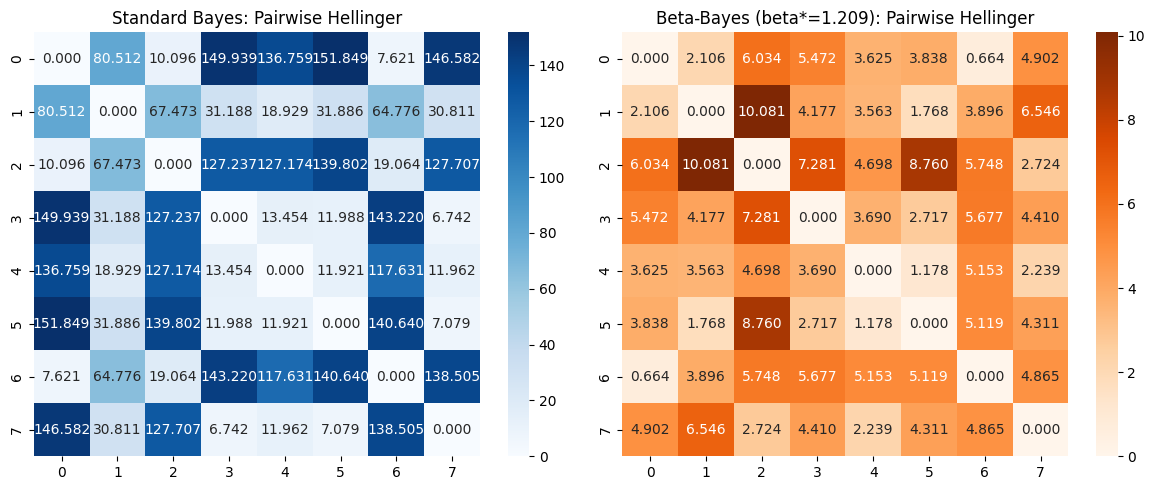

Standard Bayes: mean Hellinger (off-diag): 74.01961966926365
Beta-Bayes (beta*=1.209): mean Hellinger (off-diag): 4.472850865963632


In [11]:
# Pairwise Hellinger distances between block posteriors (standard and beta-Bayes at beta*)
import seaborn as sns

std_key = BETA_MODELS[0][0]
beta_star_key = BETA_MODELS[2][0]
std_block_params = all_block_params[std_key]
beta_block_params = all_block_params[beta_star_key]

hell_std = np.zeros((K_blocks, K_blocks))
hell_beta = np.zeros((K_blocks, K_blocks))
for i in range(K_blocks):
    for j in range(K_blocks):
        if i < j:
            h_s, _ = hellinger_nig_closed_form(std_block_params[i], std_block_params[j])
            h_b, _ = hellinger_nig_closed_form(beta_block_params[i], beta_block_params[j])
            hell_std[i, j] = hell_std[j, i] = h_s
            hell_beta[i, j] = hell_beta[j, i] = h_b

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(hell_std, ax=axes[0], cmap='Blues', annot=True, fmt='.3f', cbar=True)
axes[0].set_title('Standard Bayes: Pairwise Hellinger')
sns.heatmap(hell_beta, ax=axes[1], cmap='Oranges', annot=True, fmt='.3f', cbar=True)
axes[1].set_title(f'Beta-Bayes (beta*={float(beta_star):.3f}): Pairwise Hellinger')
plt.tight_layout()
plt.show()

triu_idx = np.triu_indices(K_blocks, k=1)
print('Standard Bayes: mean Hellinger (off-diag):', np.mean(hell_std[triu_idx]))
print(f'Beta-Bayes (beta*={float(beta_star):.3f}): mean Hellinger (off-diag):', np.mean(hell_beta[triu_idx]))


In [12]:
# Parameter-inference stability across all block pairs (Table 4):
# mean L2 distance between posterior means and mean Frobenius norm between
# posterior covariances, for Standard Bayes and beta=1.1/beta*/1.3/1.5.

def pairwise_distances(block_params):
    l2, fro = [], []
    for i in range(K_blocks):
        mu_i, V_i = block_params[i]['mu'], block_params[i]['V']
        for j in range(i + 1, K_blocks):
            mu_j, V_j = block_params[j]['mu'], block_params[j]['V']
            l2.append(np.linalg.norm(mu_i - mu_j))
            fro.append(np.linalg.norm(V_i - V_j, ord='fro'))
    return np.array(l2), np.array(fro)

table4_rows = []
for label, bval in BETA_MODELS:
    l2, fro = pairwise_distances(all_block_params[label])
    table4_rows.append((label, l2.mean(), fro.mean()))

print(f"{'Model':<22s}  {'Mean L2':>9s}  {'Mean Frobenius':>15s}")
print('-' * 52)
for label, l2_mean, fro_mean in table4_rows:
    print(f"{label:<22s}  {l2_mean:9.4f}  {fro_mean:15.4f}")


Model                     Mean L2   Mean Frobenius
----------------------------------------------------
Standard Bayes             1.3661           0.0340
beta=1.1                   1.3873           0.0621
beta*=1.209                0.2522           0.0263
beta=1.3                   0.2484           0.0282
beta=1.5                   0.2555           0.0299


In [13]:
# Predictive-inference stability across all block pairs (Table 5):
# mean d_1/2(beta) = -2 log BC between posterior predictives, on a fixed
# evaluation grid pooled from the training blocks.

rng_eval = np.random.default_rng(SEED)
X_pool = np.vstack([Xb for Xb, yb in blocks_obs])
n_eval = 200
X_star = X_pool[rng_eval.choice(len(X_pool), size=n_eval, replace=False)]

table5_rows = []
for label, bval in BETA_MODELS:
    params = all_block_params[label]
    preds = [nig_joint_predictive(p, X_star) for p in params]
    discs = [minus2logBC_mvn(*preds[i], *preds[j]) for i in range(K_blocks) for j in range(i + 1, K_blocks)]
    mean_disc = float(np.mean(discs))
    table5_rows.append((label, mean_disc))
    print(f'  {label:<22s}  mean d_1/2 = {mean_disc:.4f}')

print()
print(f"{'Model':<22s}  {'Mean d_1/2(beta)':>16s}")
print('-' * 42)
for label, mean_disc in table5_rows:
    print(f"{label:<22s}  {mean_disc:16.4f}")


  Standard Bayes          mean d_1/2 = 8.5717


  beta=1.1                mean d_1/2 = 9.5702


  beta*=1.209             mean d_1/2 = 0.5735


  beta=1.3                mean d_1/2 = 0.6331


  beta=1.5                mean d_1/2 = 0.6478

Model                   Mean d_1/2(beta)
------------------------------------------
Standard Bayes                    8.5717
beta=1.1                          9.5702
beta*=1.209                       0.5735
beta=1.3                          0.6331
beta=1.5                          0.6478
